# OPERA DISP-S1 Subsidence Analysis Notebook

**Prepared by the Water Engineering Research Center (WERC) — University of Texas at Arlington**

**Developed by** Seyed Mostafa Banihashem, Daniel Li, William Mobley, Suzanne Pierce, Nick Fang

This work extends and builds on the OPERA Cal/Val open-source repository: [https://github.com/OPERA-Cal-Val](https://github.com/OPERA-Cal-Val)

Banihashem, S. M., Li, D., Mobley, W., Pierce, S. A., & Fang, N. (2026). OPERA DISP-S1 Subsidence Analysis Notebook (0.0.1). Zenodo. https://doi.org/10.5281/zenodo.20116072

---
## What this notebook does

This notebook downloads and analyzes satellite radar data to measure ground surface movement (subsidence or uplift) in any area you choose. You will get displacement maps and velocity estimates (how fast the ground is moving per year).

## How to use it

Run the cells **from top to bottom, in order**. Do not skip any cell. Each section below tells you what you need to do or change before running.

> ### Notice before you run this notebook
>
> - **Use a longer time range when possible.** OPERA DISP-S1 measurements are relative both in time and space, so velocity estimates and cumulative displacement only become meaningful when the time series is long enough to average over seasonal and atmospheric noise. Short windows (e.g. a few months) can produce misleading rates and patterns. A multi-year window is strongly recommended.
> - **The reference-point selection is still under active research.** The automated ensemble/stability-based reference picking used here is an ongoing methodological development, not a finalized standard. Results — especially absolute values and cumulative displacement — should be interpreted as best-effort estimates, not exact ground truth. Cross-checking with GNSS or independent measurements is encouraged before drawing scientific conclusions.

## Step 1 — Load Libraries

Just run this cell. It installs required packages and may take **2–5 minutes** the first time.
Wait for the message: **`Dependencies installed successfully.`**

In [1]:
import os
import logging
import sys
from IPython.display import Markdown, display, clear_output
import ipywidgets as widgets
from ipywidgets import Layout, Button, Box, Output, VBox, Image as IPyImage, HTML, link
widgets.IntSlider()
import warnings
import base64
import glob
from getpass import getpass
from io import BytesIO
from netrc import netrc, NetrcParseError
from platform import system
import json
from pathlib import Path
from scipy.ndimage import uniform_filter
from rasterio.transform import from_bounds

%matplotlib inline
import contextily as cx
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyproj
import rasterio as rasterio
import xarray as xr
from ipyleaflet import Map, ImageOverlay, LayersControl, basemaps, TileLayer, basemap_to_tiles, Rectangle, WidgetControl, DrawControl, GeoJSON
from matplotlib import cm, colorbar, ticker

import folium
from folium.plugins import Draw
import dask
from skimage import exposure
from skimage.color import rgb2gray
import re
import datetime
import asf_search as asf
from disp_xr import product, stack as disp_stack, quality_metrics
print("Dependencies loaded successfully.")

Dependencies loaded successfully.


## Step 2 — Draw Your Study Area on the Map
1. **Draw a rectangle** on the map over your area of interest using the rectangle tool on the left side of the map.
2. Wait a few seconds — available satellite frames for that area will appear in a dropdown.
3. **Select a Frame ID** from the dropdown (if only one is found, it is auto-selected — but you still need to click Confirm in step 5).
   > ℹ️ You may see **two frame options** covering the same area — one **ascending** and one **descending** (the two Sentinel-1 viewing geometries). It does not matter which one you choose; the code processes the data correctly either way.
4. **Choose your time range** by adjusting the **Start Date** and **End Date** (and optionally **N_WORKERS** — number of download threads, default 4 is fine).
5. Click **Confirm Selection** to lock in your configuration.
> After confirming, a summary box will print your `BBOX`, `FRAME_ID`, `start_date`, `end_date`, and `N_WORKERS`. These values are **automatically stored** and will be used by the next cell — no need to copy them manually.
>
> 💡 **Tip:** Your bounding box defines the area downloaded and processed. If you want to clip the final results to a custom shape (e.g. a city boundary, watershed, or arbitrary polygon), this can be done as a **postprocessing step** after the displacement and velocity outputs are generated.

In [2]:
# ── User-configurable defaults ──────────────────────────────────────
DEFAULT_CENTER = (37.0, -120.0)   # default map center (lat, lon)
DEFAULT_ZOOM   = 6                # default zoom level

start_date = '2024-01-01'
end_date   = '2025-01-01'
N_WORKERS  = 4
OUTPUT_DIR = 'subset-ncs1'
BBOX     = None
FRAME_ID = None
output        = widgets.Output()
frame_output  = widgets.Output()
status_output = widgets.Output()

# ── Date pickers & workers slider ───────────────────────────────────
start_picker = widgets.DatePicker(
    description='Start Date',
    value=datetime.date.fromisoformat(start_date),
    style={'description_width': 'auto'}
)
end_picker = widgets.DatePicker(
    description='End Date',
    value=datetime.date.fromisoformat(end_date),
    style={'description_width': 'auto'}
)
workers_slider = widgets.IntSlider(
    value=N_WORKERS, min=1, max=4, step=1,
    description='N_WORKERS',
    style={'description_width': 'auto'}
)

# ── Frame selector dropdown (populated after ASF query) ─────────────
frame_dropdown = widgets.Dropdown(
    options=[],
    description='Frame ID:',
    style={'description_width': 'auto'},
    layout=widgets.Layout(width='350px'),
    disabled=True
)

manual_frame_input = widgets.Text(
    value='',
    placeholder='Optional manual frame ID',
    description='Manual:',
    style={'description_width': 'auto'},
    layout=widgets.Layout(width='260px'),
    disabled=True
)

confirm_button = widgets.Button(
    description='✅ Confirm Selection',
    button_style='success',
    layout=widgets.Layout(width='200px'),
    disabled=True
)

def _product_geometry(product):
    """Return a GeoJSON geometry from an ASF product when available."""
    geojson_method = getattr(product, 'geojson', None)
    if callable(geojson_method):
        try:
            feature = geojson_method()
            if isinstance(feature, dict):
                return feature.get('geometry')
        except Exception:
            pass

    geometry = getattr(product, 'geometry', None)
    if geometry is not None:
        return geometry

    if isinstance(product, dict):
        return product.get('geometry')

    return None


def _flatten_lonlat_coords(coords):
    """Yield lon/lat pairs from nested GeoJSON coordinate arrays."""
    if not coords:
        return
    if isinstance(coords[0], (int, float)) and len(coords) >= 2:
        yield coords[0], coords[1]
    else:
        for item in coords:
            yield from _flatten_lonlat_coords(item)


def _geometry_covers_bbox(geometry, lon_min, lat_min, lon_max, lat_max):
    """True when product footprint fully covers the requested bbox."""
    if geometry is None:
        return False
    if isinstance(geometry, str):
        try:
            import json as _json
            geometry = _json.loads(geometry)
        except Exception:
            return False

    try:
        from shapely.geometry import box, shape
        footprint = geometry if hasattr(geometry, 'covers') else shape(geometry)
        requested = box(lon_min, lat_min, lon_max, lat_max)
        return footprint.buffer(1e-9).covers(requested)
    except Exception:
        # Fallback: require the footprint bounding box to contain the requested bbox.
        if hasattr(geometry, 'bounds'):
            min_lon, min_lat, max_lon, max_lat = geometry.bounds
            return min_lon <= lon_min and max_lon >= lon_max and min_lat <= lat_min and max_lat >= lat_max
        coords = list(_flatten_lonlat_coords(geometry.get('coordinates', []) if isinstance(geometry, dict) else []))
        if not coords:
            return False
        lons = [p[0] for p in coords]
        lats = [p[1] for p in coords]
        return (
            min(lons) <= lon_min and max(lons) >= lon_max and
            min(lats) <= lat_min and max(lats) >= lat_max
        )


# ── Helper: query ASF for DISP-S1 frame IDs ────────────────────────
def query_frame_ids(lon_min, lat_min, lon_max, lat_max):
    """
    Search ASF for OPERA DISP-S1 products that fully cover the given BBOX.
    Returns (covered, partial), where each is {frame_id: flight_direction}.
    """
    wkt_bbox = (
        f'POLYGON(({lon_min} {lat_min},{lon_max} {lat_min},'
        f'{lon_max} {lat_max},{lon_min} {lat_max},{lon_min} {lat_min}))'
    )

    results = asf.search(
        dataset=asf.DATASET.OPERA_S1,
        processingLevel=asf.PRODUCT_TYPE.DISP_S1,
        intersectsWith=wkt_bbox,
        maxResults=250,
    )

    # Extract frame IDs from granule names:
    #   Pattern: OPERA_L3_DISP-S1_IW_F{FRAME_ID}_VV_...
    covered_frame_info = {}
    partial_frame_info = {}
    for r in results:
        name = r.properties.get('sceneName', '') or r.properties.get('fileID', '')
        match = re.search(r'_F(\d+)_', name)
        if match:
            fid = int(match.group(1))
            direction = r.properties.get('flightDirection', 'UNKNOWN')
            geometry = _product_geometry(r)
            if _geometry_covers_bbox(geometry, lon_min, lat_min, lon_max, lat_max):
                covered_frame_info.setdefault(fid, direction)
                partial_frame_info.pop(fid, None)
            elif fid not in covered_frame_info:
                partial_frame_info.setdefault(fid, direction)

    return covered_frame_info, partial_frame_info

# ── Callback: when user draws a rectangle ───────────────────────────
def handle_draw(target, action, geo_json):
    global BBOX, FRAME_ID

    if action != 'created':
        return

    coords = geo_json['geometry']['coordinates'][0]
    lons = [c[0] for c in coords]
    lats = [c[1] for c in coords]

    lon_min, lon_max = min(lons), max(lons)
    lat_min, lat_max = min(lats), max(lats)

    BBOX = f'{lon_min} {lat_min} {lon_max} {lat_max}'
    FRAME_ID = None
    frame_dropdown.options = []
    frame_dropdown.disabled = True
    manual_frame_input.value = ''
    manual_frame_input.disabled = True
    confirm_button.disabled = True

    with output:
        clear_output(wait=True)
        print(f'BBOX = \"{BBOX}\"')

    # Query ASF for matching frame IDs
    with status_output:
        clear_output(wait=True)
        print('🔍 Querying ASF for OPERA DISP-S1 frames in this area...')

    try:
        frame_info, partial_frame_info = query_frame_ids(lon_min, lat_min, lon_max, lat_max)
    except Exception as e:
        with status_output:
            clear_output(wait=True)
            print(f'❌ ASF query failed: {e}')
            print('Enter a FRAME_ID manually, then click Confirm Selection.')
        manual_frame_input.disabled = False
        confirm_button.disabled = False
        return

    with status_output:
        clear_output(wait=True)

    if not frame_info:
        with frame_output:
            clear_output(wait=True)
            print('⚠️  No OPERA DISP-S1 frame fully covers this BBOX.')
            if partial_frame_info:
                partial = ', '.join(str(fid) for fid in sorted(partial_frame_info))
                print(f'    Intersecting but partial frames: {partial}')
                print('    Draw a smaller BBOX inside one frame to avoid download bounds errors.')
            else:
                print('    Try a different region or expand your search area.')
        frame_dropdown.options = []
        frame_dropdown.disabled = True
        manual_frame_input.disabled = False
        confirm_button.disabled = False
        return

    # Populate the dropdown
    dropdown_options = [
        (f'Frame {fid} ({direction})', fid)
        for fid, direction in sorted(frame_info.items())
    ]
    frame_dropdown.options = dropdown_options
    frame_dropdown.disabled = False
    manual_frame_input.disabled = False
    confirm_button.disabled = False

    # Auto-select if only one frame
    if len(frame_info) == 1:
        fid = list(frame_info.keys())[0]
        FRAME_ID = fid
        frame_dropdown.value = fid
        with frame_output:
            clear_output(wait=True)
            print(f'✅ Found 1 frame → FRAME_ID = {FRAME_ID}')
    else:
        with frame_output:
            clear_output(wait=True)
            print(f'Found {len(frame_info)} full-coverage frames. Please select one:')

# ── Callback: confirm button ────────────────────────────────────────
def on_confirm(b):
    global FRAME_ID, BBOX, bbox_parts, start_date, end_date, N_WORKERS

    with frame_output:
        clear_output(wait=True)
        try:
            if not BBOX:
                print('Draw a rectangle on the map before confirming.')
                return

            manual_frame = manual_frame_input.value.strip()
            selected_frame = manual_frame if manual_frame else frame_dropdown.value
            if selected_frame in (None, ''):
                print('Select a frame from the dropdown or enter a manual FRAME_ID.')
                return

            if start_picker.value is None or end_picker.value is None:
                print('Choose both a start date and an end date before confirming.')
                return

            FRAME_ID   = int(selected_frame)
            start_date = start_picker.value.isoformat()
            end_date   = end_picker.value.isoformat()
            N_WORKERS  = int(workers_slider.value)
            bbox_parts = BBOX.split()
        except Exception as e:
            print(f'Could not confirm selection: {e}')
            return

        print('=' * 55)
        print('  CONFIGURATION CONFIRMED')
        print('=' * 55)
        print(f'  BBOX       = \"{BBOX}\"')
        print(f'  FRAME_ID   = {FRAME_ID}')
        print(f'  start_date = \'{start_date}\'')
        print(f'  end_date   = \'{end_date}\'')
        print(f'  N_WORKERS  = {N_WORKERS}')
        print('=' * 55)
        print()
        print('▶ You can now proceed to the next cell.')
confirm_button.on_click(on_confirm)

# ── Build the map ───────────────────────────────────────────────────
m = Map(
    center=DEFAULT_CENTER,
    zoom=DEFAULT_ZOOM,
    basemap=basemaps.OpenStreetMap.Mapnik,
    layout=widgets.Layout(height='500px')
)

draw_control = DrawControl()
draw_control.rectangle = {
    'shapeOptions': {
        'color': '#0096FF',
        'fillColor': '#0096FF',
        'fillOpacity': 0.2
    }
}
# Disable all other drawing tools
draw_control.polyline     = {}
draw_control.polygon      = {}
draw_control.circle        = {}
draw_control.marker        = {}
draw_control.circlemarker  = {}
draw_control.on_draw(handle_draw)
m.add(draw_control)
m.add(LayersControl(position='topright'))

# ── Layout everything ───────────────────────────────────────────────
css_override = widgets.HTML("""
<style>
.leaflet-draw-toolbar .leaflet-draw-draw-rectangle {
    background-image: none !important;
}
.leaflet-draw-toolbar .leaflet-draw-draw-rectangle::before {
    content: '◻'; /* Hollow square Unicode character */
    font-size: 24px;
    display: flex;
    justify-content: center;
    align-items: center;
    height: 100%;
    color: #464646;
}
</style>
""")

header = widgets.HTML(
    '<h3 style="margin:0 0 5px 0">🗺️ Draw a rectangle on the map to define your Area of Interest</h3>'
    '<p style="color:#666; margin:0 0 10px 0">'
    'The FRAME_ID will be automatically looked up from the ASF OPERA DISP-S1 catalog.</p>'
)

params_box = widgets.HBox(
    [start_picker, end_picker, workers_slider],
    layout=widgets.Layout(margin='5px 0')
)

frame_selector_box = widgets.HBox(
    [frame_dropdown, manual_frame_input, confirm_button],
    layout=widgets.Layout(margin='5px 0')
)

# Added css_override here to apply the new icon style
display(css_override) 
display(header)
display(m)
display(output)
display(status_output)
display(frame_selector_box)
display(frame_output)
display(params_box)

HTML(value="\n<style>\n.leaflet-draw-toolbar .leaflet-draw-draw-rectangle {\n    background-image: none !impor…

HTML(value='<h3 style="margin:0 0 5px 0">🗺️ Draw a rectangle on the map to define your Area of Interest</h3><p…

Map(center=[37.0, -120.0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_o…

Output()

Output()

Output()

---
## Step 3 — NASA Earthdata Login
You need a **free NASA Earthdata account** to download data.
If you don't have one, register at: [https://urs.earthdata.nasa.gov](https://urs.earthdata.nasa.gov)

>  **Before running this cell**, make sure you can log into your NASA Earthdata account at the link above and confirm it works. This avoids running into authentication errors later in the download step.

Run this cell to set up your credentials:
- **First-time users:** You will be prompted to enter your **username** and **password**. These are stored securely in a local `.netrc` file (`_netrc` on Windows) with restricted permissions so you don't have to re-enter them every time.
- **Returning users:** If credentials are already saved, the cell will ask whether you want to **update** them (`y/N`). Press Enter (or type `N`) to keep your existing credentials, or type `y` to overwrite them with new ones.

In [3]:
urs = 'urs.earthdata.nasa.gov'
prompts = ['Enter NASA Earthdata Login Username: ',
             'Enter NASA Earthdata Login Password: ']

netrc_name = "_netrc" if system() == "Windows" else ".netrc"
netrc_path = os.path.expanduser(f"~/{netrc_name}")


def _remove_machine_block(path: str, machine_host: str) -> None:
    if not os.path.isfile(path):
        return
    with open(path) as f:
        lines = f.readlines()
    out = []
    i = 0
    while i < len(lines):
        parts = lines[i].strip().split()
        if len(parts) >= 2 and parts[0] == 'machine' and parts[1] == machine_host:
            i += 1
            while i < len(lines):
                p = lines[i].strip().split()
                if p and p[0] in ('machine', 'macdef'):
                    break
                i += 1
            continue
        out.append(lines[i])
        i += 1
    with open(path, 'w') as f:
        f.writelines(out)


def write_netrc():
    username = getpass(prompt=prompts[0])
    password = getpass(prompt=prompts[1])
    with open(netrc_path, 'a') as f:
        f.write(f"\nmachine {urs}\nlogin {username}\npassword {password}\n")
    os.chmod(netrc_path, 0o600)


def has_urs_credentials():
    try:
        return netrc(netrc_path).authenticators(urs) is not None
    except (FileNotFoundError, NetrcParseError):
        return False


if not has_urs_credentials():
    if not os.path.exists(netrc_path):
        open(netrc_path, 'w').close()
    write_netrc()
else:
    ans = input('Update NASA Earthdata credentials in ~/.netrc? [y/N]: ').strip().lower()
    if ans in ('y', 'yes'):
        _remove_machine_block(netrc_path, urs)
        write_netrc()

Update NASA Earthdata credentials in ~/.netrc? [y/N]:  n


---

## Step 4 — Download the Data

Just run this cell. It downloads the satellite data files for your selected area and time period into a folder. You can change the folder name in `--output-dir` to anything you like (e.g., `my_data`).

This may take **anywhere from a few minutes to a few hours** depending on the size of your area and the length of your time period. Do not interrupt it while running.

The two cells after this will load the downloaded files and show you a preview of the data to confirm everything downloaded correctly.

>  The download and loading cells both use `OUTPUT_DIR`. Change that variable once in the configuration cell if you want a different folder name.

In [5]:
import os
import subprocess

if not BBOX or FRAME_ID is None:
    raise RuntimeError(
        "Draw a rectangle on the map, pick a frame, click Confirm Selection, then run this cell."
    )
bbox_parts = BBOX.split()
if len(bbox_parts) != 4:
    raise RuntimeError(
        f"BBOX must be four space-separated numbers (west south east north); got {BBOX!r}"
    )

werc = os.path.join(os.environ.get("WORK"), "miniconda3", "envs", "werc")

env = os.environ.copy()
env["CONDA_PREFIX"] = werc
env["PATH"] = f"{werc}/bin:" + env.get("PATH", "")
env["PROJ_DATA"] = f"{werc}/share/proj"
env["PROJ_LIB"] = f"{werc}/share/proj"
env["GDAL_DATA"] = f"{werc}/share/gdal"

cmd = [
    f"{werc}/bin/python",
    "-m", "opera_utils.cli",
    "disp-s1-download",
    "--output-dir", OUTPUT_DIR,
    "--bbox",
    *bbox_parts,
    "--frame-id", str(FRAME_ID),
    "--start-datetime", str(start_date),
    "--end-datetime", str(end_date),
    "--num-workers", str(N_WORKERS),
]
print(cmd)
subprocess.run(cmd, check=True, env=env)

['/work/06659/wmobley/ls6/miniconda3/envs/werc/bin/python', '-m', 'opera_utils.cli', 'disp-s1-download', '--output-dir', 'subset-ncs1', '--bbox', '-95.99109', '29.508895', '-95.439343', '29.785789', '--frame-id', '8882', '--start-datetime', '2016-01-01', '--end-datetime', '2025-01-01', '--num-workers', '4']


Found 236 urls for Frame 8882
Subsetting to Rows: slice(2904, 3969, None), cols: slice(4629, 6386, None)
100%|██████████| 236/236 [24:19<00:00,  6.18s/it] 


CompletedProcess(args=['/work/06659/wmobley/ls6/miniconda3/envs/werc/bin/python', '-m', 'opera_utils.cli', 'disp-s1-download', '--output-dir', 'subset-ncs1', '--bbox', '-95.99109', '29.508895', '-95.439343', '29.785789', '--frame-id', '8882', '--start-datetime', '2016-01-01', '--end-datetime', '2025-01-01', '--num-workers', '4'], returncode=0)

**Set the directory name, then run.** The following cell loads your downloaded files and displays a quick summary plus a sample map so you can verify the data looks correct before proceeding.

>  This cell reads from `OUTPUT_DIR`, the same folder used by the download cell (default: `"subset-ncs1"`). If you changed `OUTPUT_DIR` in the configuration cell, both cells will stay in sync.

v1.0, size: 236


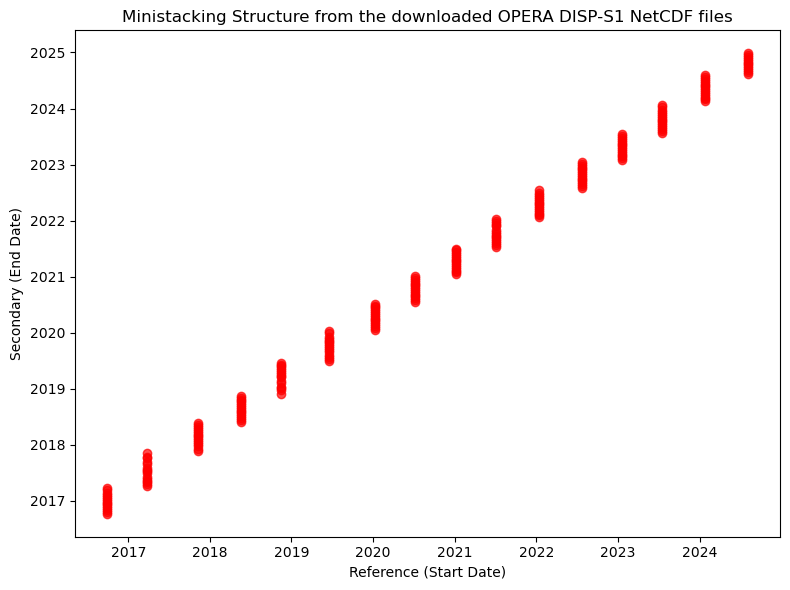

Files information:
    project level  product mode frame_id polarizarion          start_date  \
0     OPERA    L3  DISP-S1   IW   F08882           VV 2016-09-27 00:26:23   
1     OPERA    L3  DISP-S1   IW   F08882           VV 2016-09-27 00:26:23   
2     OPERA    L3  DISP-S1   IW   F08882           VV 2016-09-27 00:26:23   
3     OPERA    L3  DISP-S1   IW   F08882           VV 2016-09-27 00:26:23   
4     OPERA    L3  DISP-S1   IW   F08882           VV 2016-09-27 00:26:23   
..      ...   ...      ...  ...      ...          ...                 ...   
231   OPERA    L3  DISP-S1   IW   F08882           VV 2024-08-04 00:27:00   
232   OPERA    L3  DISP-S1   IW   F08882           VV 2024-08-04 00:27:00   
233   OPERA    L3  DISP-S1   IW   F08882           VV 2024-08-04 00:27:00   
234   OPERA    L3  DISP-S1   IW   F08882           VV 2024-08-04 00:27:00   
235   OPERA    L3  DISP-S1   IW   F08882           VV 2024-08-04 00:27:00   

               end_date version   production_date  \
0  

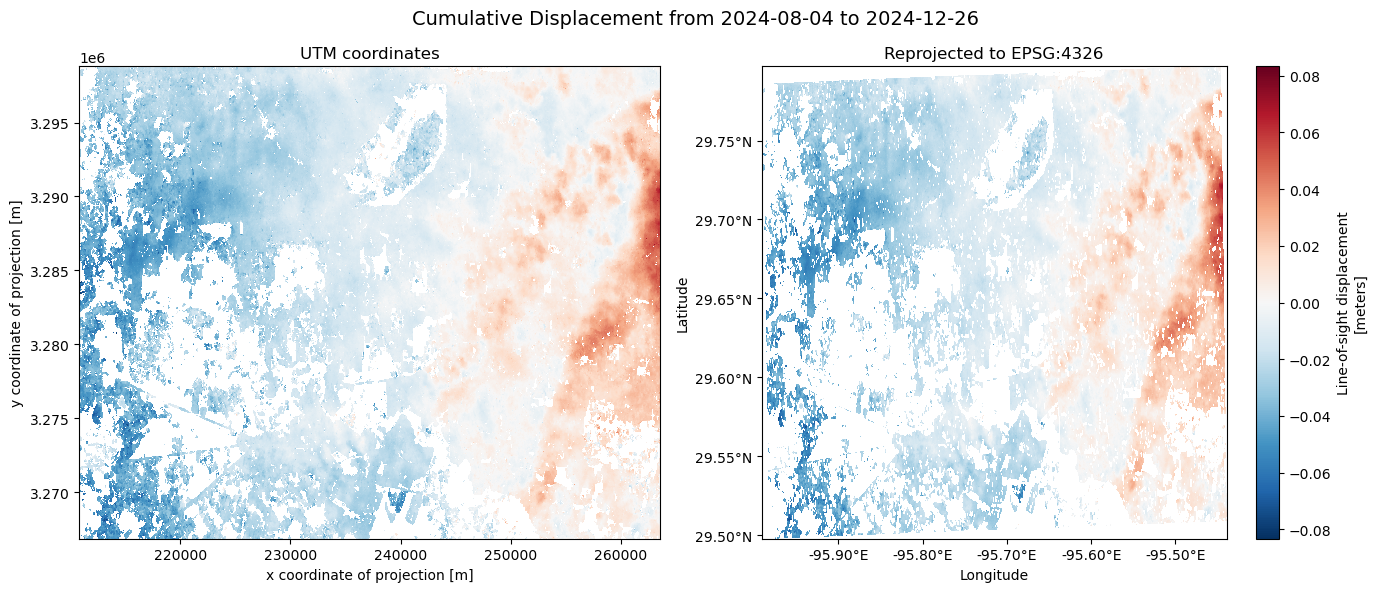

In [6]:
# Load displacement info from the directory
nc_dir = OUTPUT_DIR
disp_df = product.get_disp_info(nc_dir)

# Group by version
versions = {}
for version in disp_df["version"].unique():
    df = disp_df[disp_df["version"] == version].copy()
    versions[version] = df
    print(f"{version}, size: {df.shape[0]}")

# Plot Date1 vs Date2 for each version
for version, df in versions.items():
    df["date1"] = pd.to_datetime(df["date1"], format="%Y%m%d")
    df["date2"] = pd.to_datetime(df["date2"], format="%Y%m%d")

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(df["date1"], df["date2"], alpha=0.7, marker="o", color="r")
    ax.set_xlabel("Reference (Start Date)")
    ax.set_ylabel("Secondary (End Date)")
    ax.set_title("Ministacking Structure from the downloaded OPERA DISP-S1 NetCDF files")
    plt.tight_layout()
    plt.show()
    
print('Files information:')
print(disp_df)

# Sample file showing
# Load last file
row = disp_df.iloc[-1]
ds = xr.open_dataset(row.path)

# Format dates
d1 = pd.to_datetime(row.date1, format="%Y%m%d").date()
d2 = pd.to_datetime(row.date2, format="%Y%m%d").date()
title = f"Cumulative Displacement from {d1} to {d2}"

# Mask displacement
da = ds.where(ds.recommended_mask == 1).isel(time=-1).displacement

# Reproject to lat/lon
da.rio.write_crs(pyproj.CRS(ds.spatial_ref.attrs['crs_wkt']).to_epsg(), inplace=True)
da.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)
da_4326 = da.rio.reproject("EPSG:4326", resampling=rasterio.enums.Resampling.bilinear)

# Plot side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: UTM
da.plot.imshow(ax=ax1, cmap="RdBu_r", add_colorbar=False)
ax1.set_title("UTM coordinates")

# Right: Lat/Lon
im = da_4326.plot.imshow(ax=ax2, cmap="RdBu_r", add_colorbar=True)
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.2f}°E"))
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:.2f}°N"))
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.set_title("Reprojected to EPSG:4326")

# Shared title and layout
fig.suptitle(title, fontsize=14)
plt.tight_layout()
plt.show()

---

## Step 5 — Combine Files into a Time Series

Just run this cell. It merges all downloaded files into a single dataset ordered by time.
The printed output will show you how many time steps and pixels are in your dataset.


In [7]:
warnings.filterwarnings("ignore", message=".*data_vars.*", category=FutureWarning)

stack_prod = disp_stack.combine_disp_product(disp_df)
stack_prod = stack_prod.isel(time=slice(1, None))
stack_prod["displacement"] = stack_prod["displacement"] - stack_prod.isel(time=0).displacement
epsg = pyproj.CRS(stack_prod.spatial_ref.attrs['crs_wkt']).to_epsg()
print('Stack information:')
print(stack_prod)

Stack information:
<xarray.Dataset> Size: 21GB
Dimensions:                         (time: 236, y: 1065, x: 1757)
Coordinates:
  * y                               (y) float64 9kB 3.299e+06 ... 3.267e+06
  * x                               (x) float64 14kB 2.109e+05 ... 2.635e+05
  * time                            (time) datetime64[ns] 2kB 2016-10-09T00:2...
Data variables: (12/13)
    spatial_ref                     (time) int64 2kB 0 0 0 0 0 0 ... 0 0 0 0 0 0
    reference_time                  (time) datetime64[ns] 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    displacement                    (time, y, x) float64 4GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    short_wavelength_displacement   (time, y, x) float32 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    recommended_mask                (time, y, x) float32 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    connected_component_labels      (time, y, x) float32 2GB dask.array<chunksize=(1, 5

---
## Step 6 — Find the Best Reference Point
InSAR data measures *relative* movement — everything is measured compared to one fixed location called the **reference point**. That point must be on stable (non-moving) ground.

**Run the first cell** — it computes three intrinsic pixel-quality layers from OPERA DISP-S1 and displays them as maps:
- **Mean Temporal Coherence** — phase stability over time
- **Recommended Mask Coverage** — fraction of valid acquisitions
- **PS Mask Fraction** — persistent-scatterer behaviour

**Run the second cell** — it automatically identifies the most stable region of the scene (the *anchor zone*) and selects the top **25 reference pixels** inside it. The final displacement field is referenced to the **median** of those 25 pixels, which suppresses the bias from any single unstable pixel.

A summary table with the top reference candidates (rank, score, lat, lon) is printed, followed by a stability-score map showing the anchor zone outline and a representative reference marker, plus a histogram of the score distribution.

>  **Reminder:** As noted at the top of the notebook, automated reference-point selection is still under active research. The results should be interpreted as best-effort estimates, not exact ground truth, and benefit from cross-checking with GNSS or independent measurements.
>
**Prefer manual selection?** If you already know a stable reference location for your AOI (e.g. from prior studies, a bedrock outcrop, or local GNSS knowledge), you can override the automated picker by running the **manual reference cell** below instead. This follows the original OPERA Cal-Val convention.

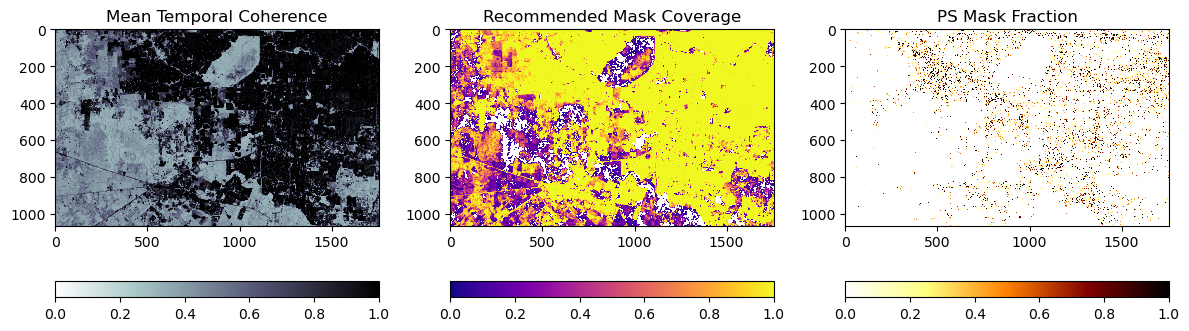

In [8]:
# Quality metrics for reference-pixel selection
stack_quality = stack_prod.chunk({"time": -1})
ref_dates, indices = np.unique(stack_quality.reference_time, return_index=True)
ministack_ref = stack_prod.isel(time=indices).chunk({"time": -1})
if ministack_ref.persistent_scatterer_mask.sizes["time"] <= 2:
    print("Not enough ministack steps to compute a quality summary. At least 2 required.")

# ── Compute the three intrinsic quality layers ─────────────────────
mean_temp_coh = stack_prod["temporal_coherence"].mean(dim="time").compute()
mask_coverage = (stack_prod["recommended_mask"] == 1).mean(dim="time").astype(float).compute()
ps_fraction   = stack_prod["persistent_scatterer_mask"].mean(dim="time").compute()

# ── Plot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
im1 = ax[0].imshow(np.ma.masked_equal(mean_temp_coh.values, 0), cmap="bone_r",   clim=[0, 1], interpolation="nearest")
im2 = ax[1].imshow(np.ma.masked_equal(mask_coverage.values, 0), cmap="plasma",   clim=[0, 1], interpolation="nearest")
im3 = ax[2].imshow(np.ma.masked_equal(ps_fraction.values,   0), cmap="afmhot_r", clim=[0, 1], interpolation="nearest")
for a, im in zip(ax, [im1, im2, im3]):
    fig.colorbar(im, ax=a, location="bottom")
for a, t in zip(ax, ["Mean Temporal Coherence", "Recommended Mask Coverage", "PS Mask Fraction"]):
    a.set_title(t)
plt.tight_layout()
plt.show()

FRAME_ID (auto-resolved from filenames): 8882
Loaded persisted anchor for FRAME 8882: (29.79640°N, -95.42684°E)  ←  reference_anchor_FRAME8882.json
✓ Selected 25 reference pixels in anchor zone using strict (PS-InSAR) thresholds.

Reference pixels (top 5 of 25 shown):
Rank     Score         Lat           Lon
----------------------------------------
1       0.9986    29.78865     -95.46543
2       0.9977    29.78529     -95.47155
3       0.9977    29.78556     -95.47156
4       0.9973    29.78892     -95.46544
5       0.9962    29.78502     -95.47155

✅ Reference correction applied (median across 25 fixed anchor-zone pixels).
   Anchor center: (29.79640°N, -95.42684°E)
   This anchor is locked for FRAME 8882; any BBOX containing it will produce identical displacement values for overlapping pixels.


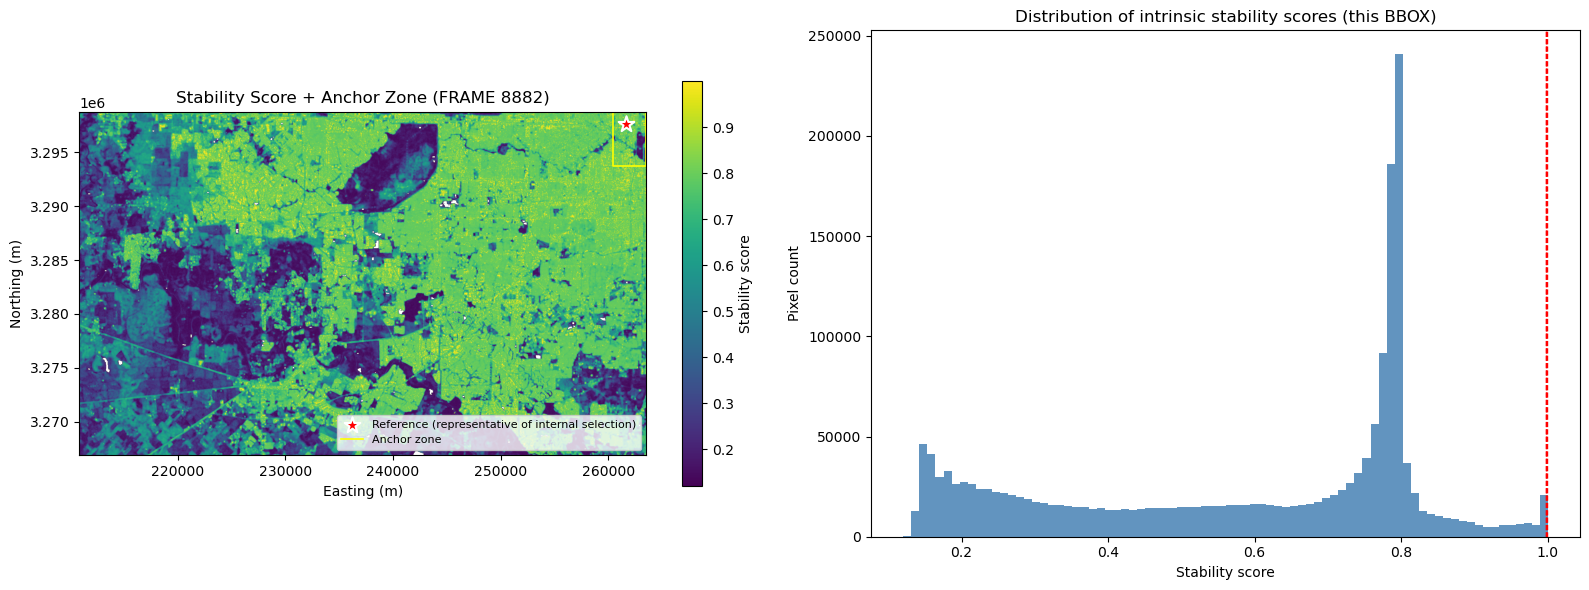

In [9]:
#  Reference-Point Selection
def _resolve_frame_id():
    paths = disp_df["path"].astype(str).tolist()
    pat = re.compile(r"_F(\d{4,5})_")
    for p in paths:
        m = pat.search(p)
        if m:
            return int(m.group(1))
    raise RuntimeError("Could not extract FRAME_ID from disp_df filenames.")

FRAME_ID = _resolve_frame_id()
print(f"FRAME_ID (auto-resolved from filenames): {FRAME_ID}")

# Tunable constants
ANCHOR_RADIUS_M           = 5000      # Half-side of anchor square (m). 5 km is a small,
                                      # tight zone that is highly likely to be inside any
                                      # reasonable user BBOX over the same region.
N_REFERENCE_PIXELS        = 25        # Median across this many top pixels inside the zone.
ANCHOR_FILE               = Path(f"reference_anchor_FRAME{FRAME_ID}.json")

# Absolute quality thresholds (BBOX-independent). These follow PS-InSAR convention.
THRESH_LEVELS = [
    # (coh_min, mask_cov_min, ps_min, label)
    (0.70, 0.95, 0.50, "strict (PS-InSAR)"),
    (0.60, 0.90, 0.30, "relaxed-1"),
    (0.50, 0.85, 0.10, "relaxed-2"),
    (0.40, 0.75, 0.00, "relaxed-3"),
]


# ── Helper: lat/lon → UTM pixel-index window ───────────────────────
def _zone_index_window(stack, lon_c, lat_c, radius_m, epsg_code):
    """Return (iy0, iy1, ix0, ix1) slicing stack to a square zone of half-side
    radius_m centered at (lon_c, lat_c). Returns None if zone falls outside stack."""
    transformer = pyproj.Transformer.from_crs("EPSG:4326", f"EPSG:{epsg_code}", always_xy=True)
    xc, yc = transformer.transform(lon_c, lat_c)

    xs = stack.x.values
    ys = stack.y.values
    if not (xs.min() - radius_m < xc < xs.max() + radius_m and
            ys.min() - radius_m < yc < ys.max() + radius_m):
        return None

    ix0 = int(np.searchsorted(xs, xc - radius_m, side="left"))
    ix1 = int(np.searchsorted(xs, xc + radius_m, side="right"))
    # y is typically descending; handle both orientations
    if ys[0] > ys[-1]:                      # descending
        iy0 = int(np.searchsorted(-ys, -(yc + radius_m), side="left"))
        iy1 = int(np.searchsorted(-ys, -(yc - radius_m), side="right"))
    else:
        iy0 = int(np.searchsorted(ys, yc - radius_m, side="left"))
        iy1 = int(np.searchsorted(ys, yc + radius_m, side="right"))

    iy0, iy1 = max(0, iy0), min(stack.sizes["y"], iy1)
    ix0, ix1 = max(0, ix0), min(stack.sizes["x"], ix1)
    if iy1 - iy0 < 3 or ix1 - ix0 < 3:
        return None
    return iy0, iy1, ix0, ix1


# ── Helper: pick best pixels inside a zone using thresholds ────────
def _select_in_zone(coh, mcov, ps, water_ok, window, n_target, x_axis, y_axis):
    """Inside the given window, find pixels passing thresholds. Returns
    (iy_global, ix_global, scores, threshold_label_used) or (None, ...).
    Tiebreaker between equally-scored pixels uses absolute UTM coords so
    ranking is the same for any BBOX containing this zone."""
    iy0, iy1, ix0, ix1 = window
    coh_z   = coh.values  [iy0:iy1, ix0:ix1]
    mcov_z  = mcov.values [iy0:iy1, ix0:ix1]
    ps_z    = ps.values   [iy0:iy1, ix0:ix1]
    water_z = water_ok.values[iy0:iy1, ix0:ix1]

    # --- MODIFICATION: Apply buffer to prevent edge-snapping ---
    buffer_px = 5  # Ignore 5 pixels on the inner edges of the anchor zone
    edge_mask = np.ones_like(coh_z, dtype=bool)
    if edge_mask.shape[0] > 2 * buffer_px and edge_mask.shape[1] > 2 * buffer_px:
        edge_mask[:buffer_px, :] = False
        edge_mask[-buffer_px:, :] = False
        edge_mask[:, :buffer_px] = False
        edge_mask[:, -buffer_px:] = False
    else:
        # Fallback if the zone is strangely small
        edge_mask[:, :] = True

    for coh_t, mcov_t, ps_t, label in THRESH_LEVELS:
        # Add edge_mask requirement so we don't pick pixels exactly on the boundary
        passes = (coh_z >= coh_t) & (mcov_z >= mcov_t) & (ps_z >= ps_t) & water_z & edge_mask
        n_pass = int(passes.sum())
        if n_pass >= n_target:
            # Composite intrinsic score (no scene-relative normalization).
            score_z = (0.45 * np.nan_to_num(coh_z)
                     + 0.35 * np.nan_to_num(mcov_z)
                     + 0.20 * np.nan_to_num(ps_z))
            
            # --- MODIFICATION: Spatial smoothing (3x3) to favor stable clusters ---
            smoothed_score_z = uniform_filter(score_z, size=3)
            
            # Round to 6 decimals so floating-point hash differences across
            # runs do not perturb the ranking of near-equal pixels.
            smoothed_score_z = np.round(smoothed_score_z, 6)
            smoothed_score_z = np.where(passes, smoothed_score_z, -np.inf)

            iy_loc, ix_loc = np.indices(smoothed_score_z.shape)
            flat_score  = smoothed_score_z.ravel()
            flat_iy_loc = iy_loc.ravel()
            flat_ix_loc = ix_loc.ravel()

            # Absolute UTM coords for tiebreaking — these are bit-identical
            # for the same physical pixel across different BBOXes.
            flat_y_utm = y_axis[iy0 + flat_iy_loc]
            flat_x_utm = x_axis[ix0 + flat_ix_loc]

            # Highest score first; then lowest UTM y; then lowest UTM x.
            order = np.lexsort((flat_x_utm, flat_y_utm, -flat_score))
            keep  = order[:n_target]
            return (iy0 + flat_iy_loc[keep],
                    ix0 + flat_ix_loc[keep],
                    flat_score[keep],
                    label)
    return None, None, None, None


# ── Helper: scan full stack for the most stable cluster ────────────
def _autopick_anchor(coh, mcov, ps, water_ok, x_axis, y_axis, epsg_code, radius_m):
    """Slide a coarse grid over the stack; pick the window with the most
    pixels passing the strictest threshold. Center of that window is the
    anchor lat/lon."""
    ny, nx = coh.shape
    # Compute strict-pass mask once
    coh_t, mcov_t, ps_t, _ = THRESH_LEVELS[0]
    strict_pass = ((coh.values   >= coh_t) &
                   (mcov.values  >= mcov_t) &
                   (ps.values    >= ps_t) &
                   water_ok.values)

    # Convert radius_m to a pixel half-window (assume ~30 m resolution from x spacing)
    dx = float(np.median(np.diff(np.sort(x_axis))))
    dx = abs(dx) if dx != 0 else 30.0
    half_pix = max(3, int(radius_m / dx))

    # Use a 2D box-sum via cumulative-sum for speed
    cs = np.cumsum(np.cumsum(strict_pass.astype(np.int32), axis=0), axis=1)
    # Pad with a leading zero row/col for uniform indexing
    cs = np.pad(cs, ((1, 0), (1, 0)), mode="constant")

    # For every candidate center, count pixels in the surrounding window
    best_count = -1
    best_yx = None
    step = max(1, half_pix // 2)
    for cy in range(half_pix, ny - half_pix, step):
        for cx_ in range(half_pix, nx - half_pix, step):
            y0, y1 = cy - half_pix, cy + half_pix
            x0, x1 = cx_ - half_pix, cx_ + half_pix
            count = int(cs[y1 + 1, x1 + 1] - cs[y0, x1 + 1]
                        - cs[y1 + 1, x0] + cs[y0, x0])
            if count > best_count:
                best_count = count
                best_yx = (cy, cx_)

    if best_yx is None or best_count < N_REFERENCE_PIXELS:
        return None, 0

    cy, cx_ = best_yx
    x_center_utm = float(x_axis[cx_])
    y_center_utm = float(y_axis[cy])
    transformer = pyproj.Transformer.from_crs(f"EPSG:{epsg_code}", "EPSG:4326", always_xy=True)
    lon_c, lat_c = transformer.transform(x_center_utm, y_center_utm)
    return (float(lon_c), float(lat_c)), best_count

#  STEP 1 — Load or auto-pick the anchor zone (lat/lon)

water_ok = (stack_prod["water_mask"].isel(time=-1) == 1).compute()

if ANCHOR_FILE.exists():
    with open(ANCHOR_FILE) as fh:
        anchor = json.load(fh)
    lon_anchor = float(anchor["lon"])
    lat_anchor = float(anchor["lat"])
    print(f"Loaded persisted anchor for FRAME {FRAME_ID}: "
          f"({lat_anchor:.5f}°N, {lon_anchor:.5f}°E)  ←  {ANCHOR_FILE}")
else:
    print(f"No persisted anchor found. Auto-picking on the loaded stack…")
    pick, n_strict = _autopick_anchor(
        mean_temp_coh, mask_coverage, ps_fraction, water_ok,
        stack_prod.x.values, stack_prod.y.values, epsg, ANCHOR_RADIUS_M,
    )
    if pick is None:
        raise RuntimeError(
            "Auto-pick failed: no zone in the current stack contains enough "
            "high-quality pixels. Either expand the BBOX or specify an anchor manually."
        )
    lon_anchor, lat_anchor = pick
    with open(ANCHOR_FILE, "w") as fh:
        json.dump({
            "frame_id": int(FRAME_ID),
            "lon": lon_anchor,
            "lat": lat_anchor,
            "radius_m": ANCHOR_RADIUS_M,
            "n_strict_pixels_at_pick_time": int(n_strict),
        }, fh, indent=2)
    print(f"Auto-picked anchor: ({lat_anchor:.5f}°N, {lon_anchor:.5f}°E) "
          f"with {n_strict} strict-pass pixels in window")
    print(f"Persisted to {ANCHOR_FILE} — future runs of this FRAME_ID will reuse it.")

#  STEP 2 — Locate anchor zone in the current stack

window = _zone_index_window(stack_prod, lon_anchor, lat_anchor, ANCHOR_RADIUS_M, epsg)
if window is None:
    raise RuntimeError(
        f"Anchor zone (lat={lat_anchor:.5f}, lon={lon_anchor:.5f}, "
        f"r={ANCHOR_RADIUS_M} m) is NOT inside the current BBOX. "
        f"Either widen the BBOX so that it contains the anchor, or "
        f"delete {ANCHOR_FILE} and run again to pick a fresh anchor for this BBOX. "
        f"Note: deleting the anchor breaks reproducibility with previous runs."
    )

#  STEP 3 — Select reference pixels inside the anchor zone

iy_sel, ix_sel, ref_scores, thresh_label = _select_in_zone(
    mean_temp_coh, mask_coverage, ps_fraction, water_ok,
    window, N_REFERENCE_PIXELS,
    stack_prod.x.values, stack_prod.y.values,
)

if iy_sel is None:
    raise RuntimeError(
        f"Anchor zone exists in this BBOX but NO pixels passed even the most "
        f"relaxed thresholds. The anchor area may have been corrupted by "
        f"flooding, vegetation regrowth, or a quality-mask bug. Inspect the "
        f"three quality plots above near (lat={lat_anchor:.5f}, "
        f"lon={lon_anchor:.5f}). To force a re-pick, delete {ANCHOR_FILE}."
    )
if thresh_label != "strict (PS-InSAR)":
    print(f"⚠️  Strict thresholds did not yield {N_REFERENCE_PIXELS} pixels in "
          f"the anchor zone. Used threshold tier: '{thresh_label}'.")
else:
    print(f"✓ Selected {N_REFERENCE_PIXELS} reference pixels in anchor zone "
          f"using strict (PS-InSAR) thresholds.")

ref_xs = stack_prod.x.values[ix_sel]
ref_ys = stack_prod.y.values[iy_sel]
proj_to_ll = pyproj.Transformer.from_crs(f"EPSG:{epsg}", "EPSG:4326", always_xy=True)
ref_lons, ref_lats = proj_to_ll.transform(ref_xs, ref_ys)

print(f"\nReference pixels (top {min(5, len(ref_scores))} of {len(ref_scores)} shown):")
print(f"{'Rank':<6}{'Score':>8}{'Lat':>12}{'Lon':>14}")
print("-" * 40)
for i in range(min(5, len(ref_scores))):
    print(f"{i+1:<6}{ref_scores[i]:>8.4f}{ref_lats[i]:>12.5f}{ref_lons[i]:>14.5f}")

#  STEP 4 — Apply the geographically-fixed reference correction

ref_disp_stack = stack_prod["displacement"].isel(
    y=xr.DataArray(iy_sel, dims="ref_pixel"),
    x=xr.DataArray(ix_sel, dims="ref_pixel"),
)                                                      # dims: (time, ref_pixel)
ref_offset = ref_disp_stack.median(dim="ref_pixel").compute()   # dims: (time,)
stack_prod["displacement"] = stack_prod["displacement"] - ref_offset

# Variables expected by downstream cells
lon, lat = float(lon_anchor), float(lat_anchor)
ref_x, ref_y = float(np.median(ref_xs)), float(np.median(ref_ys))

print(f"\n✅ Reference correction applied (median across {len(iy_sel)} fixed "
      f"anchor-zone pixels).")
print(f"   Anchor center: ({lat_anchor:.5f}°N, {lon_anchor:.5f}°E)")
print(f"   This anchor is locked for FRAME {FRAME_ID}; any BBOX containing it "
      f"will produce identical displacement values for overlapping pixels.")

#  STEP 5 — Plot: stability score map + ONE representative marker + anchor zone

# Composite intrinsic score for visualization (same metric as ranking, no masking)
stability_score = (0.45 * mean_temp_coh.fillna(0)
                 + 0.35 * mask_coverage.fillna(0)
                 + 0.20 * ps_fraction.fillna(0))
stability_score = stability_score.where(water_ok, other=np.nan)

# Pick ONE representative pixel from the 25 for display: the one nearest
# to the centroid of all 25.
_cx_utm = float(np.mean(ref_xs))
_cy_utm = float(np.mean(ref_ys))
_dist = np.sqrt((ref_xs - _cx_utm) ** 2 + (ref_ys - _cy_utm) ** 2)
_i_marker = int(np.argmin(_dist))
marker_x = float(ref_xs[_i_marker])
marker_y = float(ref_ys[_i_marker])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

extent_utm = [stack_prod.x.values.min(), stack_prod.x.values.max(),
              stack_prod.y.values.min(), stack_prod.y.values.max()]
im0 = axes[0].imshow(stability_score.values, cmap="viridis", origin="upper", extent=extent_utm)
axes[0].scatter([marker_x], [marker_y], c="red", s=140, edgecolors="white",
                linewidths=1.5, marker="*", zorder=6,
                label="Reference (representative of internal selection)")

# Draw anchor zone outline
iy0, iy1, ix0, ix1 = window
zx0, zx1 = stack_prod.x.values[ix0], stack_prod.x.values[ix1 - 1]
zy0, zy1 = stack_prod.y.values[iy0], stack_prod.y.values[iy1 - 1]
axes[0].plot([zx0, zx1, zx1, zx0, zx0],
             [zy0, zy0, zy1, zy1, zy0],
             color="yellow", linewidth=1.2, label="Anchor zone")
axes[0].set_title(f"Stability Score + Anchor Zone (FRAME {FRAME_ID})")
axes[0].set_xlabel("Easting (m)")
axes[0].set_ylabel("Northing (m)")
axes[0].legend(loc="lower right", fontsize=8)
fig.colorbar(im0, ax=axes[0], label="Stability score", shrink=0.8)

# Histogram with thresholds shown
flat = stability_score.values.ravel()
flat = flat[~np.isnan(flat)]
axes[1].hist(flat, bins=80, color="steelblue", edgecolor="none", alpha=0.85)
for s in ref_scores[:3]:
    axes[1].axvline(s, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Distribution of intrinsic stability scores (this BBOX)")
axes[1].set_xlabel("Stability score")
axes[1].set_ylabel("Pixel count")

plt.tight_layout()
plt.show()

### (Optional) Manual Reference Point — OPERA Cal-Val Style
If you have a **known stable location** for your AOI, enter its latitude and longitude in the cell below. The displacement field will be referenced to that single pixel, overriding the automated selection above.

> Only run this cell if you want to use a manual reference. Otherwise, skip it and keep the automated anchor from the previous step.

In [10]:
USE_MANUAL_REFERENCE = False
manual_lat, manual_lon = 32.3409, -109.3661

if USE_MANUAL_REFERENCE:
    lat, lon = manual_lat, manual_lon

    # Convert to UTM
    epsg = pyproj.CRS(stack_prod.spatial_ref.attrs["crs_wkt"]).to_epsg()
    proj = pyproj.Transformer.from_crs("EPSG:4326", f"EPSG:{epsg}", always_xy=True)
    ref_x, ref_y = proj.transform(lon, lat)

    # Subtract reference
    ref_disp = stack_prod.sel(x=ref_x, y=ref_y, method='nearest').displacement
    stack_prod['displacement'] = stack_prod.displacement - ref_disp
    print(f"Manual reference applied at ({lat:.5f}, {lon:.5f}).")
else:
    print("Manual reference not applied; keeping automated reference.")

Manual reference not applied; keeping automated reference.


---
## Step 7 — Cumulative Displacement Map
By running this cell, you will get:
- A **static map** showing total ground movement from start to end of your period. Red = sinking, Blue = rising. Values are in millimeters.

To save the static map as an image file, remove the `#` from the `#plt.savefig(...)` line and re-run the cell.

>  **Next cell:** an **interactive version** of the same displacement map will be generated, allowing you to pan, zoom, and inspect pixel values directly in the notebook.

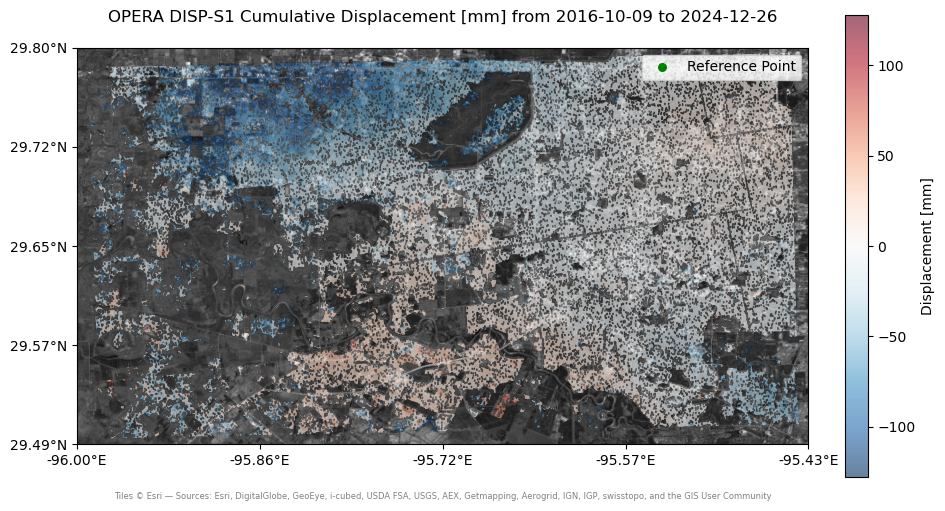

In [11]:
def get_baseimage_from_bounds(bounds, source, grayscale=False, gamma=None, log=None, zoom='auto'):
    xmin, ymin, xmax, ymax = bounds
    left, right, bottom, top = cx.plotting._reproj_bb(xmin, xmax, ymin, ymax, 'EPSG:4326', "epsg:3857")
    image, extent = cx.tile.bounds2img(left, bottom, right, top, zoom=zoom, source=source, ll=False)
    image, extent = cx.tile.warp_tiles(image, extent, t_crs='EPSG:4326', resampling=rasterio.enums.Resampling.bilinear)
    if grayscale:
        image = rgb2gray(image[:, :, :3])
    if gamma is not None:
        image = exposure.adjust_gamma(image, gamma)
    if log is not None:
        image = exposure.adjust_log(image, log)
    return image, extent

# Preprocess displacement
buffer_fraction = 0.015
da = stack_prod.isel(time=-1).displacement * 1000  # cm
mask = stack_prod.isel(time=-1).recommended_mask
water = stack_prod.isel(time=-1).water_mask
da = da.where((mask == 1) & (water == 1))

# Set CRS and reproject
da.rio.write_crs(epsg, inplace=True)
da.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)
da_4326 = da.rio.reproject("EPSG:4326", resampling=rasterio.enums.Resampling.bilinear)

# Buffer bounds
xmin, ymin, xmax, ymax = da_4326.rio.bounds()
x_pad = (xmax - xmin) * buffer_fraction
y_pad = (ymax - ymin) * buffer_fraction
buffered_bounds = [xmin - x_pad, ymin - y_pad, xmax + x_pad, ymax + y_pad]
extent = [buffered_bounds[0], buffered_bounds[2], buffered_bounds[1], buffered_bounds[3]]

# Normalize
v = np.nanpercentile(da_4326.values, [2, 98])
vmax = max(abs(v[0]), abs(v[1]))
vmin = -vmax

# Plot setup
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])

# Add basemap
bg, bg_extent = get_baseimage_from_bounds(buffered_bounds, source=cx.providers.Esri.WorldImagery, grayscale=True, gamma=0.9)
ax.imshow(bg, extent=bg_extent, cmap="gray", origin="upper", zorder=1)

# Displacement overlay
ax.imshow(da_4326.values, extent=[xmin, xmax, ymin, ymax], cmap=plt.get_cmap("RdBu_r"), vmin=vmin, vmax=vmax, alpha=0.6, origin="upper", zorder=2)

# Reference point
ax.scatter(lon, lat, color="green", s=30, label="Reference Point", zorder=3)

# Colorbar
cbar = plt.colorbar(ax.images[1], ax=ax, shrink=0.6, pad=0.04)
cbar.set_label("Displacement [mm]")

# Add ticks
ax.set_xticks(np.linspace(extent[0], extent[1], 5))
ax.set_yticks(np.linspace(extent[2], extent[3], 5))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.2f}°E"))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:.2f}°N"))
ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)

# Attribution
ax.annotate(
    "Tiles © Esri — Sources: Esri, DigitalGlobe, GeoEye, i-cubed, USDA FSA, USGS, AEX, "
    "Getmapping, Aerogrid, IGN, IGP, swisstopo, and the GIS User Community",
    xy=(0.5, -0.12), xycoords='axes fraction',
    ha='center', va='top', fontsize=6, color='gray'
)

ax.legend()
d1 = pd.to_datetime(stack_prod.time.values[0]).strftime('%Y-%m-%d')
d2 = pd.to_datetime(stack_prod.time.values[-1]).strftime('%Y-%m-%d')
ax.set_title(f"OPERA DISP-S1 Cumulative Displacement [mm] from {d1} to {d2}\n")
plt.tight_layout()
plt.show()

In [12]:
## interactive version 
# Preprocess displacement
da = stack_prod.isel(time=-1).displacement * 1000
mask = stack_prod.isel(time=-1).recommended_mask
water = stack_prod.isel(time=-1).water_mask
da = da.where((mask == 1) & (water == 1))

# Reproject
da.rio.write_crs(epsg, inplace=True)
da.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)
da_3857 = da.rio.reproject("EPSG:3857", resampling=rasterio.enums.Resampling.bilinear)

# Colormap
v = np.nanpercentile(da_3857.values, [2, 98])
vmax = max(abs(v[0]), abs(v[1]))
vmin = -vmax
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad(color=(0, 0, 0, 0))

# Create colorbar image in buffer
fig_cb, ax_cb = plt.subplots(figsize=(4, 0.3), dpi=150)
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cb = colorbar.ColorbarBase(ax_cb, cmap=cmap, norm=norm, orientation='horizontal')
cb.set_label("Displacement [mm]")
ax_cb.set_frame_on(False)

colorbar_buf = BytesIO()
fig_cb.savefig(colorbar_buf, format='png', bbox_inches='tight', transparent=True)
plt.close(fig_cb)
colorbar_buf.seek(0)

# Make colorbar ipywidget
colorbar_widget = IPyImage(
    value=colorbar_buf.read(),
    format='png',
    layout=Layout(margin='0 auto', display='block')  # Center the image
)

# Map image buffer
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
ax.axis("off")
ax.imshow(da_3857.values, vmin=vmin, vmax=vmax, cmap=cmap, origin="upper")
buf = BytesIO()
fig.savefig(buf, format="png", bbox_inches="tight", pad_inches=0, transparent=True)
plt.close(fig)
buf.seek(0)

# Lat/Lon bounds
west, south, east, north = da_3857.rio.bounds()
lon_west, lat_south = pyproj.Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True).transform(west, south)
lon_east, lat_north = pyproj.Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True).transform(east, north)
center_lon, center_lat = pyproj.Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True).transform(
    (west + east) / 2, (south + north) / 2
)

mapnik = basemap_to_tiles(basemaps.OpenStreetMap.Mapnik)
mapnik.base = True
mapnik.name = 'Mapnik Layer'

topo = basemap_to_tiles(basemaps.OpenTopoMap)
topo.base = True
topo.name = 'OpenTopo Layer'

Esritopo = basemap_to_tiles(basemaps.Esri.WorldTopoMap)
Esritopo.base = True
Esritopo.name = 'EsriTopo Layer'

Esri = basemap_to_tiles(basemaps.Esri.WorldImagery)
Esri.base = True
Esri.name = 'Esri World Imagery'

# Map
m = Map(
    center=(center_lat, center_lon),
    zoom=12,
    scroll_wheel_zoom=True,
    #basemap=basemaps.Esri.WorldImagery,
    layers = [mapnik, topo, Esritopo, Esri],
    layout=Layout(width="100%", height="700px")
)

overlay = ImageOverlay(
    url='data:image/png;base64,' + base64.b64encode(buf.read()).decode('utf-8'),
    bounds=((lat_south, lon_west), (lat_north, lon_east)),
    opacity=0.6,
    name="OPERA DISP-S1 Cumulative Displacement [mm]",
    attribution="Data: OPERA DISP-S1, Map: Esri World Imagery"
)


m.add_layer(overlay)
# Add control to toggle layers
m.add_control(LayersControl(position='topleft'))

d1 = pd.to_datetime(disp_df["date1"].iloc[0], format="%Y%m%d").date()
d2 = pd.to_datetime(disp_df["date2"].iloc[-1], format="%Y%m%d").date()

# Title widget
title_html = HTML(
    value=f"<h1 style='text-align:center;'>OPERA DISP-S1 Cumulative Displacement from {d1} to {d2}</h1>",
    layout=Layout(margin='0 0 5px 0')
)

# MiniMap Setup
mini_map = Map(
    zoom_control=False,
    attribution_control=False,
    center=m.center,
    zoom=max(m.zoom - 4, 1),
    basemap=basemap_to_tiles(basemaps.OpenStreetMap.Mapnik),
    layout=Layout(width="150px", height="150px")
)

data_bounds_rect = Rectangle(
    bounds=((lat_south, lon_west), (lat_north, lon_east)),
    color="red",
    fill_opacity=0.15,
    weight=2
)
mini_map.add_layer(data_bounds_rect)

# Dynamic update: Keep minimap in sync with main map
def update_minimap_view(change):
    mini_map.center = m.center
    mini_map.zoom = max(m.zoom - 4, 1)

m.observe(update_minimap_view, names=["center", "zoom", "bounds"])

# Add minimap to main map
minimap_control = WidgetControl(widget=mini_map, position="bottomleft")
m.add(minimap_control)

# Display everything
VBox([title_html, colorbar_widget, m])

## Generate GeoTiff
This cell exports the cumulative displacement map as a **GeoTIFF** file, ready to use in GIS software (QGIS, ArcGIS, etc.) or for further postprocessing (clipping to custom shapes, overlaying with other layers, etc.).

In [13]:
# Output path
d1 = pd.to_datetime(stack_prod.time.values[0]).strftime('%Y%m%d')
d2 = pd.to_datetime(stack_prod.time.values[-1]).strftime('%Y%m%d')
out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, f"OPERA_DISP_S1_cumulative_2_{d1}_{d2}.tif")

# da_4326 is already reprojected, masked, and in mm — use it directly
data = da_4326.values.astype(np.float32)

p_low = float(np.nanpercentile(da_4326.values, 1))
p_high = float(np.nanpercentile(da_4326.values, 99))
data = np.clip(data, p_low, p_high)  # already float32 from earlier
print(f"Export range after clip: {p_low:.2f} to {p_high:.2f} mm")

# Spatial metadata from the DataArray
xmin_t, ymin_t, xmax_t, ymax_t = da_4326.rio.bounds()
height, width = data.shape
transform = from_bounds(xmin_t, ymin_t, xmax_t, ymax_t, width, height)

with rasterio.open(
    out_path,
    mode="w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype="float32",
    crs="EPSG:4326",
    transform=transform,
    nodata=np.nan,
    compress="deflate",          # lossless, ~50% smaller
    tiled=True,
    blockxsize=256,
    blockysize=256,
) as dst:
    dst.write(data, 1)
    dst.update_tags(
        long_name="Cumulative LOS Displacement",
        units="mm",
        source="OPERA DISP-S1",
        date_start=d1,
        date_end=d2,
        reference_lon=str(round(float(lon), 6)),
        reference_lat=str(round(float(lat), 6)),
    )

print(f"✓ GeoTIFF saved → {out_path}")
print(f"  CRS     : EPSG:4326")
print(f"  Size    : {width} × {height} px")
print(f"  Bounds  : {xmin_t:.4f}°E  {ymin_t:.4f}°N  →  {xmax_t:.4f}°E  {ymax_t:.4f}°N")
print(f"  NoData  : NaN  (masked pixels preserved)")

Export range after clip: -144.41 to 41.08 mm
✓ GeoTIFF saved → outputs/OPERA_DISP_S1_cumulative_2_20161009_20241226.tif
  CRS     : EPSG:4326
  Size    : 1836 × 996 px
  Bounds  : -95.9910°E  29.4977°N  →  -95.4394°E  29.7970°N
  NoData  : NaN  (masked pixels preserved)


---
## Step 9 — Velocity Map (Rate of Movement per Year)
This step estimates how fast the ground is moving at every pixel, expressed in **mm/year**. The velocity is computed by fitting a **linear trend** through the full displacement time series at each pixel (least-squares regression of displacement vs. time in decimal years).

**Run the cells in this section in order.** You will get:
- A **velocity dataset** (`velocity_ds`) stored as an xarray Dataset, with metadata (units, start/end/reference dates) attached for downstream use or export.
- A **static velocity map** with a satellite basemap, showing the rate of movement in **mm/year**. Red = sinking, Blue = rising. Masked pixels (low-quality or water) are excluded.

To save the static map as an image file, remove the `#` from the `#plt.savefig("sample")` line and re-run the cell.

>  **Reminder:** Velocity estimates are most reliable over **long time ranges** (multi-year). Short windows can produce noisy or misleading rates due to seasonal and atmospheric effects.

In [14]:
# Extract the displacement time series from stack_prod
disp = stack_prod['displacement'].values  # shape: (nt, ny, nx)
times = stack_prod['time'].values         # datetime64 array
ny, nx = disp.shape[1:]                   # spatial dimensions
nt = disp.shape[0]                        # number of time steps

# Convert time to decimal years
def _decimal_year(dates):
    """Convert datetime64 array to decimal years."""
    import pandas as pd
    dates = pd.to_datetime(dates)
    return dates.year + (dates.dayofyear - 1) / 365.25

tdecimal = _decimal_year(times)  # shape (nt,)
A = np.vstack([tdecimal, np.ones_like(tdecimal)]).T  # shape: (nt, 2)

# Reshape displacement to (nt, ny*nx)
y = disp.reshape(nt, -1)

# Solve least squares for linear fit: displacement = velocity * time + intercept
coef, *_ = np.linalg.lstsq(A, y, rcond=None)  # shape: (2, ny*nx)

# Extract velocity (slope) and reshape back to (ny, nx)
vel = coef[0].reshape(ny, nx).astype(np.float32)

# Create new DataArray in xarray
vel_da = xr.DataArray(vel, dims=("y", "x"), coords={"y": stack_prod.y, "x": stack_prod.x},
    attrs={
        "long_name": "Velocity",
        "units": "m/year",
        "description": "Linear velocity estimated from displacement time series",
        "start_date": str(times[0]),
        "end_date": str(times[-1]),
        "ref_date": str(times[0]),
    },
)

# Add it to a new dataset (or optionally merge with stack_prod)
velocity_ds = xr.Dataset({"velocity": vel_da})

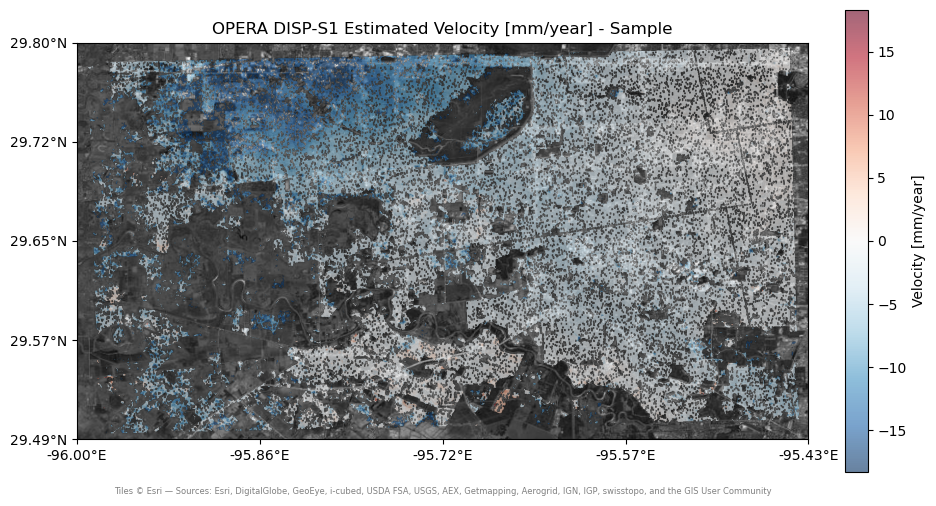

In [15]:
# Convert velocity to cm/year and apply mask
vel_masked = (vel_da * 1000).where((stack_prod.isel(time=-1).recommended_mask == 1) & (stack_prod.isel(time=-1).water_mask == 1))

# Reproject to EPSG:4326
vel_masked.rio.write_crs(epsg, inplace=True)
vel_masked.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)
vel_4326 = vel_masked.rio.reproject("EPSG:4326", resampling=rasterio.enums.Resampling.bilinear)

# Buffer bounds
buffer_fraction = 0.015
xmin, ymin, xmax, ymax = vel_4326.rio.bounds()
x_pad = (xmax - xmin) * buffer_fraction
y_pad = (ymax - ymin) * buffer_fraction
buffered_bounds = [xmin - x_pad, ymin - y_pad, xmax + x_pad, ymax + y_pad]
extent = [buffered_bounds[0], buffered_bounds[2], buffered_bounds[1], buffered_bounds[3]]

# Normalize values
v = np.nanpercentile(vel_4326.values, [2, 98])
vmax = max(abs(v[0]), abs(v[1]))
vmin = -vmax

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])

# Basemap
bg, bg_extent = get_baseimage_from_bounds(buffered_bounds, source=cx.providers.Esri.WorldImagery, grayscale=True, gamma=0.9)
ax.imshow(bg, extent=bg_extent, cmap="gray", origin="upper", zorder=1)

# Velocity overlay
im = ax.imshow( vel_4326.values, extent=[xmin, xmax, ymin, ymax], cmap="RdBu_r", vmin=vmin, vmax=vmax, alpha=0.6, origin="upper", zorder=2)

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.04)
cbar.set_label("Velocity [mm/year]")

# Ticks and formatting
ax.set_xticks(np.linspace(extent[0], extent[1], 5))
ax.set_yticks(np.linspace(extent[2], extent[3], 5))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.2f}°E"))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:.2f}°N"))
ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)

# Attribution
ax.annotate(
    "Tiles © Esri — Sources: Esri, DigitalGlobe, GeoEye, i-cubed, USDA FSA, USGS, AEX, "
    "Getmapping, Aerogrid, IGN, IGP, swisstopo, and the GIS User Community",
    xy=(0.5, -0.12), xycoords='axes fraction',
    ha='center', va='top', fontsize=6, color='gray'
)

ax.set_title("OPERA DISP-S1 Estimated Velocity [mm/year] - Sample")
plt.tight_layout()
#plt.savefig("sample")
plt.show()

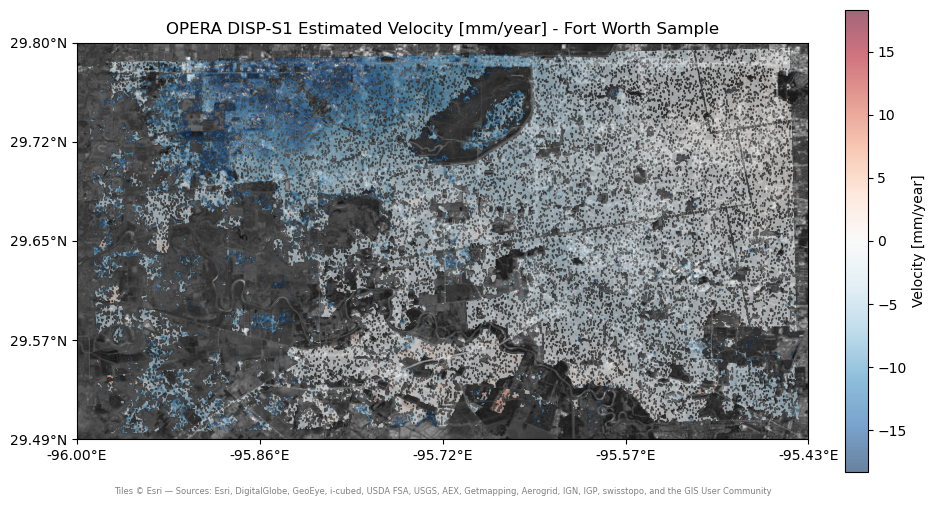

In [16]:
# Convert velocity to cm/year and apply mask
vel_masked = (vel_da * 1000).where((stack_prod.isel(time=-1).recommended_mask == 1) & (stack_prod.isel(time=-1).water_mask == 1))

# Reproject to EPSG:4326
vel_masked.rio.write_crs(epsg, inplace=True)
vel_masked.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)
vel_4326 = vel_masked.rio.reproject("EPSG:4326", resampling=rasterio.enums.Resampling.bilinear)

# Buffer bounds
buffer_fraction = 0.015
xmin, ymin, xmax, ymax = vel_4326.rio.bounds()
x_pad = (xmax - xmin) * buffer_fraction
y_pad = (ymax - ymin) * buffer_fraction
buffered_bounds = [xmin - x_pad, ymin - y_pad, xmax + x_pad, ymax + y_pad]
extent = [buffered_bounds[0], buffered_bounds[2], buffered_bounds[1], buffered_bounds[3]]

# Normalize values
v = np.nanpercentile(vel_4326.values, [2, 98])
vmax = max(abs(v[0]), abs(v[1]))
vmin = -vmax

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])

# Basemap
bg, bg_extent = get_baseimage_from_bounds(buffered_bounds, source=cx.providers.Esri.WorldImagery, grayscale=True, gamma=0.9)
ax.imshow(bg, extent=bg_extent, cmap="gray", origin="upper", zorder=1)

# Velocity overlay
im = ax.imshow( vel_4326.values, extent=[xmin, xmax, ymin, ymax], cmap="RdBu_r", vmin=vmin, vmax=vmax, alpha=0.6, origin="upper", zorder=2)

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.04)
cbar.set_label("Velocity [mm/year]")

# Ticks and formatting
ax.set_xticks(np.linspace(extent[0], extent[1], 5))
ax.set_yticks(np.linspace(extent[2], extent[3], 5))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.2f}°E"))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:.2f}°N"))
ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)

# Attribution
ax.annotate(
    "Tiles © Esri — Sources: Esri, DigitalGlobe, GeoEye, i-cubed, USDA FSA, USGS, AEX, "
    "Getmapping, Aerogrid, IGN, IGP, swisstopo, and the GIS User Community",
    xy=(0.5, -0.12), xycoords='axes fraction',
    ha='center', va='top', fontsize=6, color='gray'
)

ax.set_title("OPERA DISP-S1 Estimated Velocity [mm/year] - Fort Worth Sample")
plt.tight_layout()
#plt.savefig("sample")
plt.show()